In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

In [4]:
# same link as for finches -> carnivora
df = pd.read_csv("https://raw.githubusercontent.com/roualdes/data/refs/heads/master/carnivora.csv")

In [5]:
df.head()

,Order,SuperFamily,Family,Genus,Species,FW,SW,FB,SB,LS,GL,BW,WA,AI,LY,AM,IB
0,Carnivora,Caniformia,Canidae,Canis,Canis lupus,31.1,33.1,130.0,132.3,5.5,63.0,425.0,35.0,NaN,177.0,913,12
1,Carnivora,Caniformia,Canidae,Canis,Canis latrans,9.7,10.6,84.5,88.3,6.2,61.5,225.0,98.0,NaN,NaN,365,12
2,Carnivora,Caniformia,Canidae,Canis,Canis adustus,10.6,11.3,53.5,51.8,4.3,63.3,NaN,NaN,NaN,127.0,NaN,NaN
3,Carnivora,Caniformia,Canidae,Canis,Canis mesomelas,7.2,7.7,52.0,56.8,3.8,60.0,NaN,61.0,270.0,NaN,392,NaN
4,Carnivora,Caniformia,Canidae,Lycaon,Lycaon pictus,22.2,22.0,128.0,129.0,8.8,70.5,365.0,77.0,390.0,132.0,t 132,13


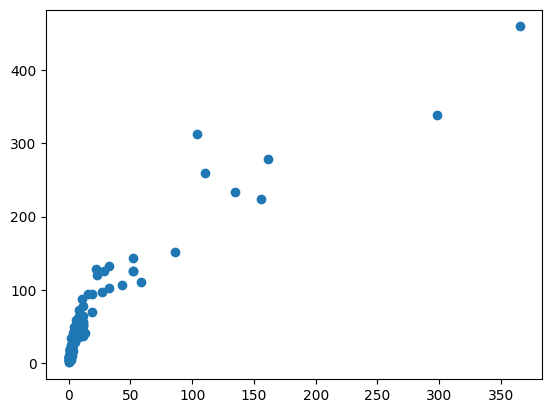

In [9]:
plt.scatter(df["SW"], df["SB"])

In [46]:
model = smf.ols("SB ~ SW + I(SW* SW)", data = df)
fit = model.fit()

In [47]:
fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                     SB   R-squared:                       0.915
Model:                            OLS   Adj. R-squared:                  0.913
Method:                 Least Squares   F-statistic:                     585.6
Date:                Thu, 20 Nov 2025   Prob (F-statistic):           4.93e-59
Time:                        08:58:06   Log-Likelihood:                -503.95
No. Observations:                 112   AIC:                             1014.
Df Residuals:                     109   BIC:                             1022.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     21.3680      2.423      8.818      0.000      16.565      26.171
SW             2.2409      0.110     20.355      0.000       2.023       2.459
I(SW * SW)    -0.0032      0.000     -8.822      0.000      -0.004      -0.003
==============================================================================
Omnibus:                       26.840   Durbin-Watson:                   1.275
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               70.392
Skew:                           0.848   Prob(JB):                     5.18e-16
Kurtosis:                       6.494   Cond. No.                     1.83e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.83e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

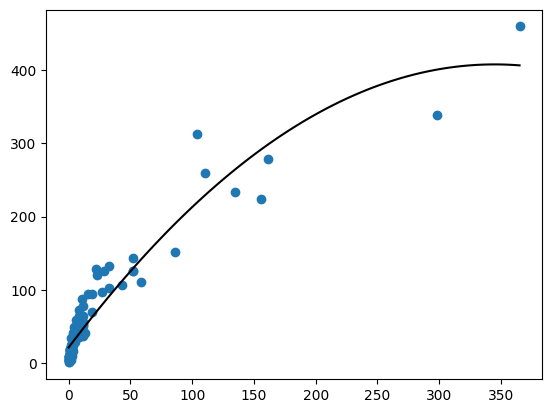

In [50]:
mn, mx = np.min(df["SW"]), np.max(df["SW"])
ndf = pd.DataFrame.from_dict({
    "SW": np.linspace(mn, mx, 101)
})
ndf["yhat"] = fit.predict(ndf)
plt.scatter(df["SW"], df["SB"])
plt.plot(ndf["SW"], ndf["yhat"], color = "black")

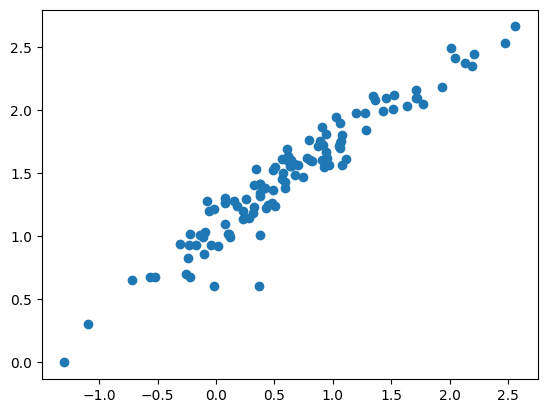

In [51]:
plt.scatter(np.log10(df["SW"]), np.log10(df["SB"]))

In [52]:
model = smf.ols("np.log10(SB) ~ np.log10(SW)", data = df)
fit = model.fit()

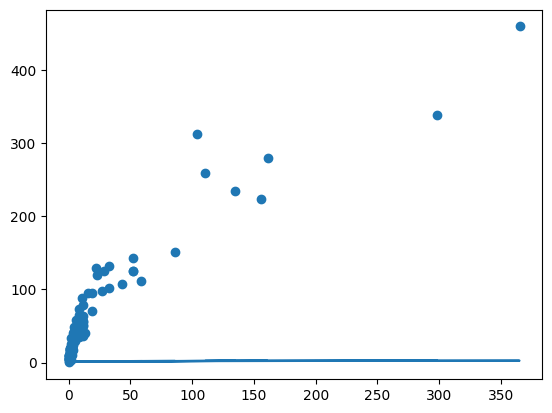

In [53]:
yhat = fit.predict(df)
plt.scatter(df["SW"], df["SB"])
plt.plot(df["SW"], yhat)

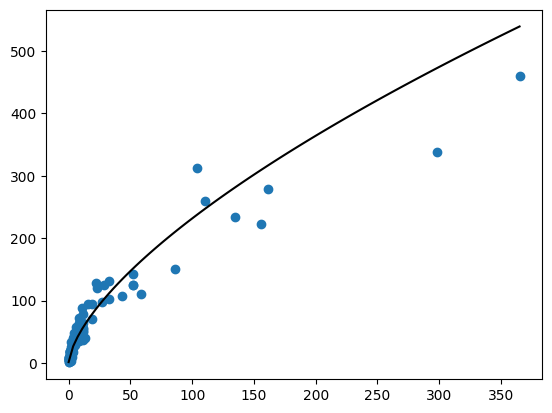

In [55]:
mn, mx = np.min(df["SW"]), np.max(df["SW"])
ndf = pd.DataFrame.from_dict({
    "SW": np.linspace(mn, mx, 101)
})
ndf["yhat"] = fit.predict(ndf)
plt.scatter(df["SW"], df["SB"])
plt.plot(ndf["SW"], 10 ** ndf["yhat"], color = "black")

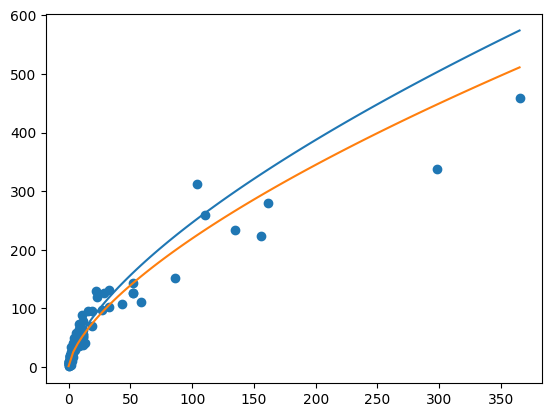

In [32]:
# instantiate and fit model here: log10 both x, y, and 
# unique "intercepts" by SuperFamily

mn, mx = np.min(df["SW"]), np.max(df["SW"])
x = np.linspace(mn, mx, 101)
ndf = pd.DataFrame.from_dict({
    "SuperFamily": np.repeat(["Caniformia", "Feliformia"], 101),
    "SW": np.tile(x, 2)
})
ndf["yhat"] = fit.predict(ndf)


# make plot here: one line for each SuperFamily